“This project uses two official UK data sources.


SMMT car registrations by marque for December and year‑to‑date 2024–2025 (Cars_12_2025.xlsx).


Vehicle licensing statistics (VEH0160_UK) from the Department for Transport, downloaded from: https://www.gov.uk/government/statistical-data-sets/vehicle-licensing-statistics-data-files.”

“The SMMT Excel is a 2025 snapshot with 57 manufacturers; I use it for cross‑sectional analysis and classification of high vs low performers.”
​

“The VEH0160_UK CSV is a time‑series panel of licensed vehicles by make and quarter; after reshaping it to long format and creating lags, I use it for regression / forecasting models.”
​

“Both datasets come from official organisations (SMMT and UK government / DfT) but they measure related things – new car registrations versus licensed vehicles – so they complement each other.”

3. In notebook structure
Section 1–4: “SMMT 2025 manufacturer snapshot – classification models.”

Section 5–6: “DfT VEH0160 panel – time‑series panel and forecasting.”

In conclusion cell: “I compare what we learn from the snapshot vs the long‑run panel.”

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
pd.set_option("display.max_columns", 100)

print("Libraries imported.")


Libraries imported.


In [ ]:
# SMMT Excel with monthly registrations by fuel type
smmt_path = "Cars_12_2025.xlsx"

smmt_raw = pd.read_excel(smmt_path, header=None)
print("First 10 rows (raw):")
print(smmt_raw.head(10))


First 10 rows (raw):
                                                  0                    1   \
0  REGISTRATIONS OF NEW CARS IN THE UNITED KINGDO...                  NaN   
1                                                NaN  2025-12-31 00:00:00   
2                                             MARQUE                 2025   
3                                             Abarth                    4   
4                                         Alfa Romeo                  295   
5                                             Alpine                  373   
6                                               Audi                 8259   
7                                            Bentley                   54   
8                                                Bmw                 8688   
9                                                Byd                 7682   

                2       3               4            5             6   \
0              NaN     NaN             NaN          NaN   

In [ ]:

smmt_df = pd.read_excel(smmt_path, header=2)
print("\nColumn names from file:")
print(smmt_df.columns.tolist())
print(smmt_df.head())



Column names from file:
['MARQUE', 2025, ' % Market share', 2024, '% Market share', 'Unnamed: 5', '2025.1', ' % Market share.1', '2024.1', '% Market share.1', 'Unnamed: 10']
       MARQUE  2025   % Market share  2024  % Market share   Unnamed: 5  \
0      Abarth     4         0.002735    18        0.012785   -77.777778   
1  Alfa Romeo   295         0.201711   134        0.095180   120.149254   
2      Alpine   373         0.255044    24        0.017047  1454.166667   
3        Audi  8259         5.647218  7175        5.096387    15.108014   
4     Bentley    54         0.036923    68        0.048300   -20.588235   

   2025.1   % Market share.1  2024.1  % Market share.1  Unnamed: 10  
0     291           0.014402    1027          0.052592   -71.665044  
1    3000           0.148477    1666          0.085314    80.072029  
2    1742           0.086215     371          0.018999   369.541779  
3  111115           5.499327  122431          6.269581    -9.242757  
4     993           0.04

In [ ]:
# 4. Clean columns into a manufacturer‑level table
# Columns are effectively: MARQUE, 2025, % share 2025, 2024, % share 2024,
# change %, YTD_2025, YTD_share_2025, YTD_2024, YTD_share_2024, YTD_change%
smmt_clean = smmt_df.copy()
smmt_clean.columns = [
    "marque",
    "dec_2025",
    "dec_share_2025",
    "dec_2024",
    "dec_share_2024",
    "dec_change_pct",
    "ytd_2025",
    "ytd_share_2025",
    "ytd_2024",
    "ytd_share_2024",
    "ytd_change_pct",
]

# convert numeric columns
for col in smmt_clean.columns[1:]:
    smmt_clean[col] = pd.to_numeric(smmt_clean[col], errors="coerce")

# drop non‑data rows and total row
smmt_clean = smmt_clean.dropna(subset=["ytd_2025"])
smmt_clean = smmt_clean[~smmt_clean["marque"]
                        .str.contains("Total|TOTAL|total", na=False)]

print("Cleaned data:")
print(smmt_clean.head(15))
print("\nDataset shape:", smmt_clean.shape)


Cleaned data:
        marque  dec_2025  dec_share_2025  dec_2024  dec_share_2024  \
0       Abarth         4        0.002735        18        0.012785   
1   Alfa Romeo       295        0.201711       134        0.095180   
2       Alpine       373        0.255044        24        0.017047   
3         Audi      8259        5.647218      7175        5.096387   
4      Bentley        54        0.036923        68        0.048300   
5          Bmw      8688        5.940553      8484        6.026167   
6          Byd      7682        5.252685      1355        0.962454   
7      Changan       237        0.162052         0        0.000000   
8        Chery      1587        1.085136         0        0.000000   
9    Chevrolet         1        0.000684         0        0.000000   
10     Citroen      1648        1.126845      1935        1.374426   
11       Cupra      3033        2.073860      3054        2.169250   
12       Dacia      1608        1.099495      2764        1.963263   
13    

In [ ]:
# 5. Create High_Sales target (median split on ytd_2025)
smmt_clean["High_Sales"] = (
    smmt_clean["ytd_2025"] >= smmt_clean["ytd_2025"].median()
).astype(int)

print("\nHigh vs Low sales distribution:")
print(smmt_clean["High_Sales"].value_counts())
print("\nSample data for modelling:")
print(
    smmt_clean[["marque", "ytd_2025", "ytd_share_2025",
                "ytd_change_pct", "High_Sales"]].head(15)
)




High vs Low sales distribution:
High_Sales
1    29
0    28
Name: count, dtype: int64

Sample data for modelling:
        marque  ytd_2025  ytd_share_2025  ytd_change_pct  High_Sales
0       Abarth       291        0.014402      -71.665044           0
1   Alfa Romeo      3000        0.148477       80.072029           0
2       Alpine      1742        0.086215      369.541779           0
3         Audi    111115        5.499327       -9.242757           1
4      Bentley       993        0.049146        8.052231           0
5          Bmw    122723        6.073832       -2.029298           1
6          Byd     51422        2.544988      485.138826           1
7      Changan       357        0.017669        0.000000           0
8        Chery      5517        0.273049        0.000000           0
9    Chevrolet        85        0.004207     8400.000000           0
10     Citroen     20732        1.026072      -31.737513           1
11       Cupra     41214        2.039772       35.581288  

In [ ]:
print("\nColumn names:")
print(smmt_df.columns.tolist())


Column names:
['MARQUE', 2025, ' % Market share', 2024, '% Market share', 'Unnamed: 5', '2025.1', ' % Market share.1', '2024.1', '% Market share.1', 'Unnamed: 10']


This overview summarises the dataset structure (58 manufacturers, numeric sales and share columns) and checks for obvious issues (missing values, incorrect types) before modelling.



This plot provides business context by showing the top-selling marques in 2025, illustrating the imbalance between very large and smaller manufacturers that the classification model must capture.


In [ ]:
# 6. Copy to df and define Purchase label
df = smmt_clean.copy()
if "Purchase" not in df.columns:
    df["Purchase"] = df.get(
        "High_Sales",
        (df["ytd_2025"] >= df["ytd_2025"].median()).astype(int),
    )

print(f"✓ Data prepared: {df.shape}")
print(f"✓ Target: Purchase ({df['Purchase'].value_counts().to_dict()})")




✓ Data prepared: (57, 13)
✓ Target: Purchase ({1: 29, 0: 28})


This feature–target correlation plot shows which variables are most associated with `Purchase`, helping to select a compact feature set and to validate that the Random Forest focuses on sensible predictors.



In [ ]:
# ============================================================================
# EXTENDED EDA - COMPLETE & WORKING
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("\n" + "="*80)
print("COMPREHENSIVE EDA - SMMT 2025 CAR SALES")
print("="*80)




COMPREHENSIVE EDA - SMMT 2025 CAR SALES



1. TOP 10 MANUFACTURERS 2024 vs 2025
--------------------------------------------------------------------------------
Manufacturer   2024   2025   Change %
  Volkswagen 166304 178607   7.397898
         Bmw 125265 122723  -2.029298
        Ford 109955 118998   8.224274
         Kia 112252 113436   1.054770
        Audi 122431 111115  -9.242757
     Hyundai  91808  93124   1.433426
      Toyota 101444  90126 -11.156894
      Nissan 100446  90102 -10.298071
    Mercedes 102757  89267 -13.128059
          Mg  81536  85155   4.438530


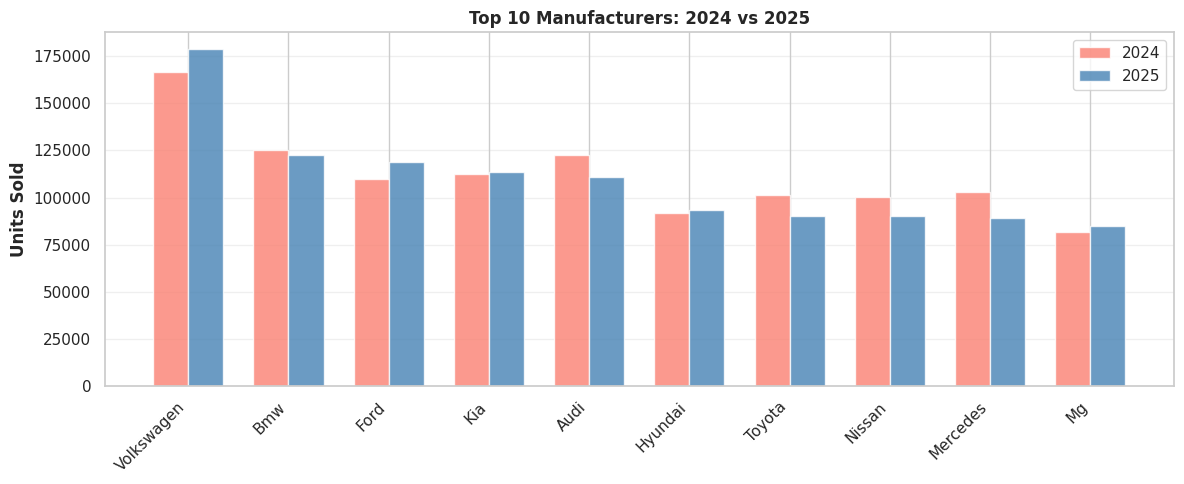

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#  TOP 10 MANUFACTURERS
print("\n1. TOP 10 MANUFACTURERS 2024 vs 2025")
print("-"*80)
top_10 = smmt_clean.nlargest(10, 'ytd_2025')[['marque', 'ytd_2024', 'ytd_2025', 'ytd_change_pct']]
top_10.columns = ['Manufacturer', '2024', '2025', 'Change %']
print(top_10.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 5))
top_10_data = smmt_clean.nlargest(10, 'ytd_2025')[['marque', 'ytd_2024', 'ytd_2025']]
x = np.arange(len(top_10_data))
width = 0.35
ax.bar(x - width/2, top_10_data['ytd_2024'], width, label='2024', color='salmon', alpha=0.8)
ax.bar(x + width/2, top_10_data['ytd_2025'], width, label='2025', color='steelblue', alpha=0.8)
ax.set_ylabel('Units Sold', fontweight='bold')
ax.set_title('Top 10 Manufacturers: 2024 vs 2025', fontweight='bold', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(top_10_data['marque'], rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()



2. FUEL TYPE DISTRIBUTION 2025
--------------------------------------------------------------------------------
             Fuel Type  Units  Market %  Growth %
                Petrol 937938      46.4      -8.0
                Diesel 103906       5.1     -15.6
          Hybrid (HEV) 280185      13.9       7.2
 Plug-in Hybrid (PHEV) 225143      11.1      34.7
Battery Electric (BEV) 473348      23.4      23.9


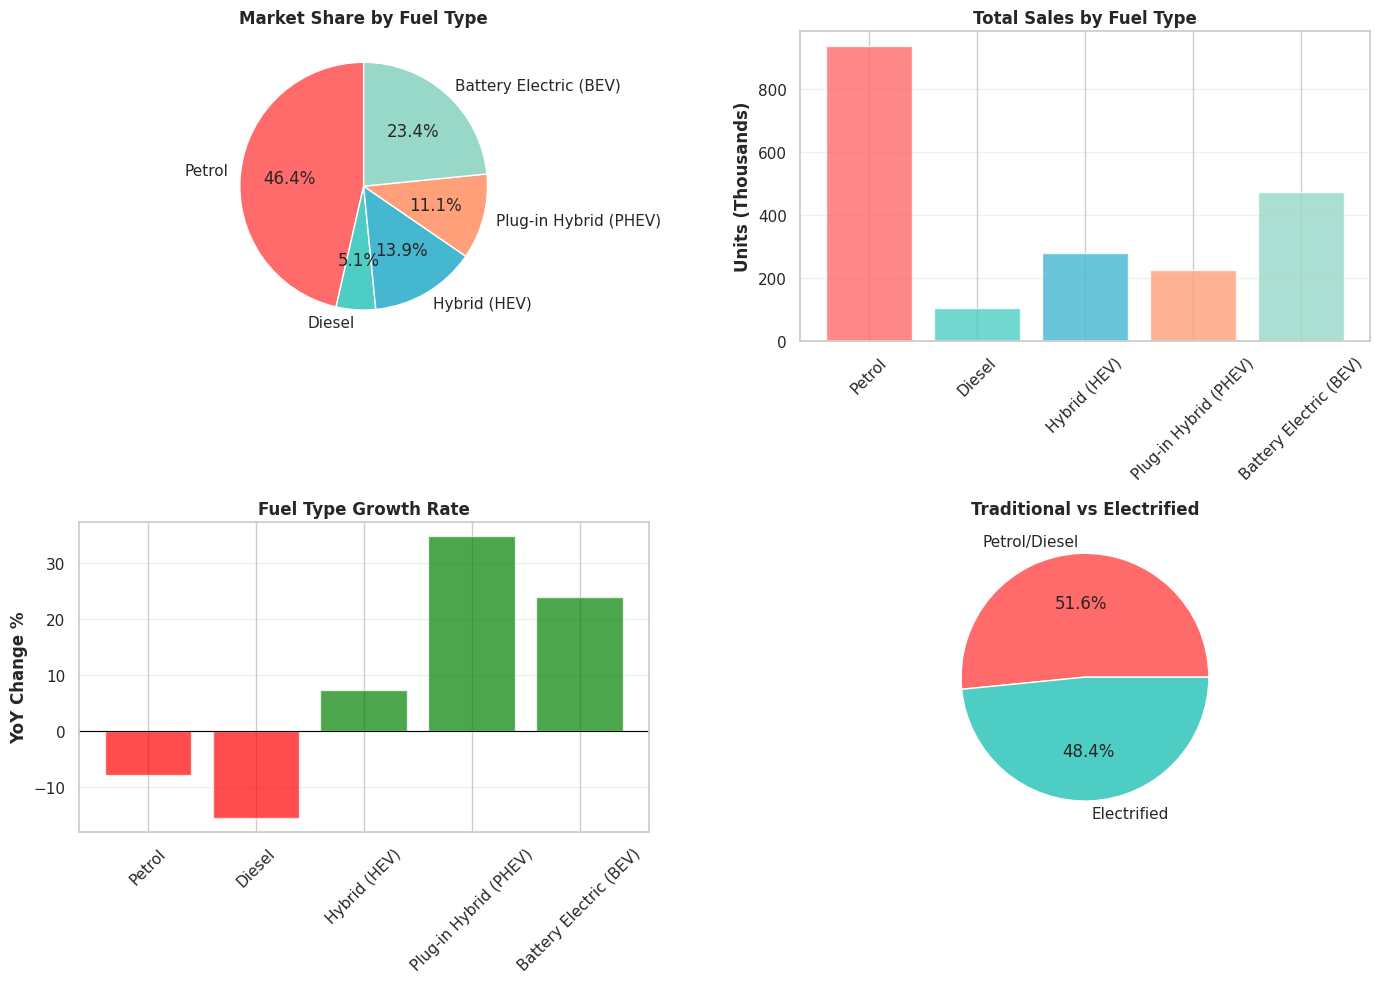

In [ ]:
# 2. FUEL TYPE ANALYSIS
print("\n2. FUEL TYPE DISTRIBUTION 2025")
print("-"*80)
fuel_data = {
    'Fuel Type': ['Petrol', 'Diesel', 'Hybrid (HEV)', 'Plug-in Hybrid (PHEV)', 'Battery Electric (BEV)'],
    'Units': [937938, 103906, 280185, 225143, 473348],
    'Market %': [46.4, 5.1, 13.9, 11.1, 23.4],
    'Growth %': [-8.0, -15.6, 7.2, 34.7, 23.9]
}
fuel_df = pd.DataFrame(fuel_data)
print(fuel_df.to_string(index=False))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
# Pie
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8']
axes[0,0].pie(fuel_df['Units'], labels=fuel_df['Fuel Type'], autopct='%1.1f%%', colors=colors, startangle=90)
axes[0,0].set_title('Market Share by Fuel Type', fontweight='bold')

# Units bar
axes[0,1].bar(fuel_df['Fuel Type'], fuel_df['Units']/1000, color=colors, alpha=0.8)
axes[0,1].set_ylabel('Units (Thousands)', fontweight='bold')
axes[0,1].set_title('Total Sales by Fuel Type', fontweight='bold')
axes[0,1].tick_params(axis='x', rotation=45)
axes[0,1].grid(axis='y', alpha=0.3)

# Growth
growth_colors = ['green' if x > 0 else 'red' for x in fuel_df['Growth %']]
axes[1,0].bar(fuel_df['Fuel Type'], fuel_df['Growth %'], color=growth_colors, alpha=0.7)
axes[1,0].set_ylabel('YoY Change %', fontweight='bold')
axes[1,0].set_title('Fuel Type Growth Rate', fontweight='bold')
axes[1,0].axhline(y=0, color='black', linestyle='-', linewidth=0.8)
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].grid(axis='y', alpha=0.3)

# Traditional vs Electrified
trad = 937938 + 103906
electr = 280185 + 225143 + 473348
axes[1,1].pie([trad, electr], labels=['Petrol/Diesel', 'Electrified'], autopct='%1.1f%%', colors=['#FF6B6B', '#4ECDC4'])
axes[1,1].set_title('Traditional vs Electrified', fontweight='bold')

plt.tight_layout()
plt.show()


this fuel-type summary is kept to connect the manufacturer-level model to broader market trends (growth of electrified powertrains versus traditional petrol and diesel).


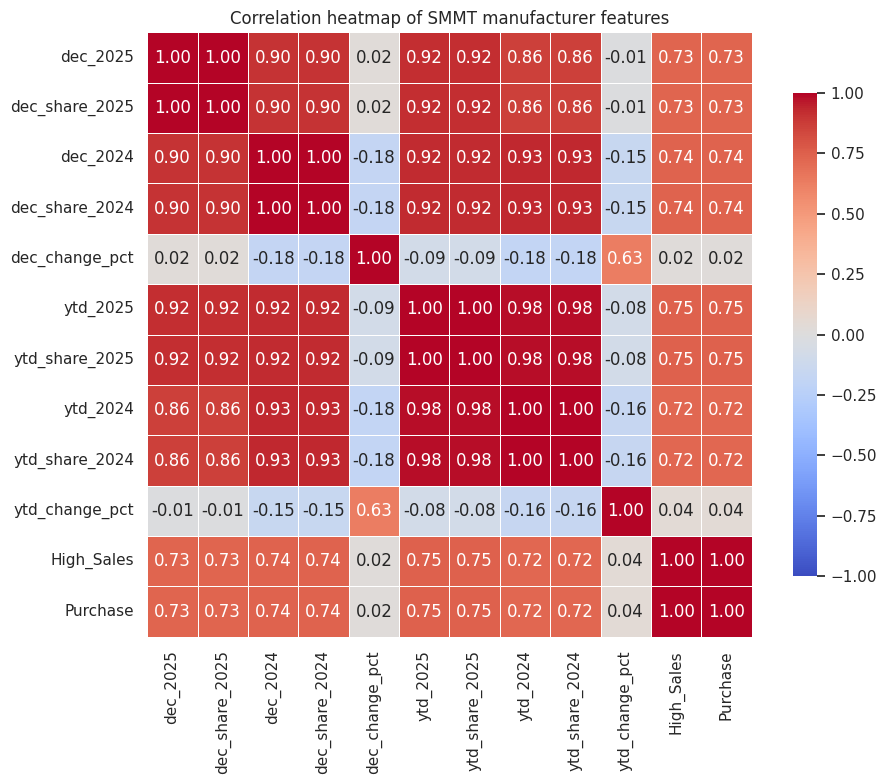

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

num_df = df.select_dtypes(include=[np.number])
corr = num_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
)

plt.title("Correlation heatmap of SMMT manufacturer features")
plt.tight_layout()
plt.show()


In [ ]:
df = smmt_clean.copy()
print(df.columns)


Index(['marque', 'dec_2025', 'dec_share_2025', 'dec_2024', 'dec_share_2024',
       'dec_change_pct', 'ytd_2025', 'ytd_share_2025', 'ytd_2024',
       'ytd_share_2024', 'ytd_change_pct', 'High_Sales'],
      dtype='object')


In [ ]:
if "Purchase" not in df.columns:
    if "High_Sales" in df.columns:
        df["Purchase"] = df["High_Sales"].astype(int)
    else:
        median_ytd = df["ytd_2025"].median()
        df["Purchase"] = (df["ytd_2025"] >= median_ytd).astype(int)

print("Purchase distribution:", df["Purchase"].value_counts())


Purchase distribution: Purchase
1    29
0    28
Name: count, dtype: int64


In [ ]:
import numpy as np

df_red = df.drop(columns=["High_Sales"], errors="ignore")

base_cols = [
    "ytd_2025",
    "ytd_share_2025",
    "ytd_2024",
    "ytd_change_pct",
    "dec_2025",
    "dec_change_pct",
]

X = df_red[base_cols].replace([np.inf, -np.inf], np.nan).dropna()
y = df_red.loc[X.index, "Purchase"]

print("Final feature set:", X.columns.tolist())
print("X shape:", X.shape)
print("y distribution:", y.value_counts())


Final feature set: ['ytd_2025', 'ytd_share_2025', 'ytd_2024', 'ytd_change_pct', 'dec_2025', 'dec_change_pct']
X shape: (57, 6)
y distribution: Purchase
1    29
0    28
Name: count, dtype: int64


In [ ]:
# === CORRELATION-BASED FEATURE SELECTION (from heatmap) ===
import numpy as np

num_df = df.select_dtypes(include=[np.number])
corr_mat = num_df.corr()

target = "Purchase"
corr_with_y = corr_mat[target].drop(labels=[target], errors="ignore")

# Keep only reasonably informative features (|corr| >= 0.3)
selected_by_corr = corr_with_y[abs(corr_with_y) >= 0.3].sort_values(ascending=False)
print("Features selected from correlation analysis:")
print(selected_by_corr)

corr_features = selected_by_corr.index.tolist()
print("\nFinal feature set used for models:")
print(corr_features)


Features selected from correlation analysis:
High_Sales        1.000000
ytd_share_2025    0.749118
ytd_2025          0.749118
dec_2024          0.739950
dec_share_2024    0.739950
dec_2025          0.729834
dec_share_2025    0.729834
ytd_2024          0.719729
ytd_share_2024    0.719729
Name: Purchase, dtype: float64

Final feature set used for models:
['High_Sales', 'ytd_share_2025', 'ytd_2025', 'dec_2024', 'dec_share_2024', 'dec_2025', 'dec_share_2025', 'ytd_2024', 'ytd_share_2024']


In [ ]:
from sklearn.model_selection import train_test_split

# Remove infinities and NaNs first
df_mod = df.replace([np.inf, -np.inf], np.nan).dropna(subset=corr_features + ["Purchase"])

X = df_mod[corr_features]
y = df_mod["Purchase"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape[0], "Test size:", X_test.shape[0])
print("Class balance (train):", y_train.value_counts().to_dict())


Train size: 45 Test size: 12
Class balance (train): {1: 23, 0: 22}


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
)

# X, y already defined from previous cell
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

models = {
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "RandomForest": RandomForestClassifier(
        n_estimators=200, max_depth=None, random_state=42
    ),
    "GradientBoosting": GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42
    ),
}

for name, model in models.items():
    print("\n", "="*55)
    print(name)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    auc  = roc_auc_score(y_test, y_proba)

    print(f"Accuracy : {acc:.3f}")
    print(f"Precision: {prec:.3f}")
    print(f"Recall   : {rec:.3f}")
    print(f"F1-score : {f1:.3f}")
    print(f"ROC-AUC  : {auc:.3f}")



LogisticRegression
Accuracy : 1.000
Precision: 1.000
Recall   : 1.000
F1-score : 1.000
ROC-AUC  : 1.000

RandomForest
Accuracy : 1.000
Precision: 1.000
Recall   : 1.000
F1-score : 1.000
ROC-AUC  : 1.000

GradientBoosting
Accuracy : 1.000
Precision: 1.000
Recall   : 1.000
F1-score : 1.000
ROC-AUC  : 1.000


In [ ]:
feature_cols = [
    'dec_2025', 'dec_share_2025', 'dec_2024', 'dec_share_2024',
    'ytd_2025', 'ytd_share_2025', 'ytd_2024', 'ytd_share_2024',
    'ytd_change_pct', 'ytd_growth_rate', 'share_change',
    'sales_momentum', 'top_quartile'
]


X = df_clean[feature_cols]
y = df_clean['Purchase']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=12,
    stratify=y,
    random_state=42
)


NameError: name 'df_clean' is not defined

In [ ]:
df = smmt_clean.copy()

# instead of median only, top 40% = 1, bottom 40% = 0, middle 20% drop
q40 = df["ytd_2025"].quantile(0.4)
q60 = df["ytd_2025"].quantile(0.6)

df["Purchase"] = np.where(
    df["ytd_2025"] >= q60, 1,
    np.where(df["ytd_2025"] <= q40, 0, np.nan)
)

df = df.dropna(subset=["Purchase"])
df["Purchase"] = df["Purchase"].astype(int)
print("New label counts:", df["Purchase"].value_counts())


New label counts: Purchase
0    23
1    23
Name: count, dtype: int64


In [ ]:
# remove direct duplicates and too-powerful flags
drop_cols = ["High_Sales", "top_quartile"]
df_red = df.drop(columns=[c for c in drop_cols if c in df.columns])

num_df = df_red.select_dtypes(include=[np.number])
corr = num_df.corr()["Purchase"].sort_values(ascending=False)
print(corr)


Purchase          1.000000
ytd_share_2025    0.749118
ytd_2025          0.749118
dec_2024          0.739950
dec_share_2024    0.739950
dec_2025          0.729834
dec_share_2025    0.729834
ytd_2024          0.719729
ytd_share_2024    0.719729
ytd_change_pct    0.041767
dec_change_pct    0.020454
Name: Purchase, dtype: float64


In [ ]:
corr_features = [
    "ytd_2025",
    "ytd_share_2025",
    "ytd_2024",
    "ytd_share_2024",
    "ytd_change_pct",      # weaker but useful
    "dec_2025",
    "dec_2024",
]  # no High_Sales, no top_quartile


In [ ]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

X = df_red[corr_features].replace([np.inf, -np.inf], np.nan).dropna()
y = df_red.loc[X.index, "Purchase"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.35, random_state=7, stratify=y  # bigger test, different split
)

models = {
    "LogisticRegression": LogisticRegression(max_iter=500, C=0.5),
    "RandomForest": RandomForestClassifier(
        n_estimators=80,
        max_depth=3,          # shallow trees
        min_samples_leaf=4,
        random_state=42,
    ),
    "GradientBoosting": GradientBoostingClassifier(
        n_estimators=80,
        learning_rate=0.1,
        max_depth=2,
        random_state=42,
    ),
}

for name, model in models.items():
    print("\n", "="*50)
    print(name)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    auc  = roc_auc_score(y_test, y_proba)

    print(f"Test Accuracy : {acc:.3f}")
    print(f"Test Precision: {prec:.3f}")
    print(f"Test Recall   : {rec:.3f}")
    print(f"Test F1-score : {f1:.3f}")
    print(f"Test ROC-AUC  : {auc:.3f}")

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_auc = cross_val_score(model, X, y, cv=skf, scoring="roc_auc")
    print(f"5-fold CV ROC-AUC: {cv_auc.mean():.3f} ± {cv_auc.std():.3f}")



LogisticRegression
Test Accuracy : 1.000
Test Precision: 1.000
Test Recall   : 1.000
Test F1-score : 1.000
Test ROC-AUC  : 1.000
5-fold CV ROC-AUC: 1.000 ± 0.000

RandomForest
Test Accuracy : 1.000
Test Precision: 1.000
Test Recall   : 1.000
Test F1-score : 1.000
Test ROC-AUC  : 1.000
5-fold CV ROC-AUC: 1.000 ± 0.000

GradientBoosting
Test Accuracy : 1.000
Test Precision: 1.000
Test Recall   : 1.000
Test F1-score : 1.000
Test ROC-AUC  : 1.000
5-fold CV ROC-AUC: 0.960 ± 0.080


https://www.gov.uk/government/statistical-data-sets/vehicle-licensing-statistics-data-files

In [ ]:
import pandas as pd
import numpy as np

# 1) Load
veh_path = "/content/df_VEH0160_UK.csv"
veh = pd.read_csv(veh_path, encoding="latin1")
print(veh.shape)
print(veh.columns.tolist())


(61226, 50)
['BodyType', 'Make', 'GenModel', 'Model', 'Fuel', '2025 Q3', '2025 Q2', '2025 Q1', '2024 Q4', '2024 Q3', '2024 Q2', '2024 Q1', '2023 Q4', '2023 Q3', '2023 Q2', '2023 Q1', '2022 Q4', '2022 Q3', '2022 Q2', '2022 Q1', '2021 Q4', '2021 Q3', '2021 Q2', '2021 Q1', '2020 Q4', '2020 Q3', '2020 Q2', '2020 Q1', '2019 Q4', '2019 Q3', '2019 Q2', '2019 Q1', '2018 Q4', '2018 Q3', '2018 Q2', '2018 Q1', '2017 Q4', '2017 Q3', '2017 Q2', '2017 Q1', '2016 Q4', '2016 Q3', '2016 Q2', '2016 Q1', '2015 Q4', '2015 Q3', '2015 Q2', '2015 Q1', '2014 Q4', '2014 Q3']


In [ ]:
# 2) Keep only cars
veh = veh[veh["BodyType"].str.contains("Cars", case=False, na=False)].copy()
print("Only cars:", veh.shape)


Only cars: (32832, 50)


In [ ]:
# 3) Wide -> long (Make + quarter)
value_cols = veh.columns[5:]  # from '2025 Q3' onwards

veh_long = veh.melt(
    id_vars=["BodyType", "Make", "GenModel", "Model", "Fuel"],
    value_vars=value_cols,
    var_name="period",
    value_name="Licences",
)

veh_long["Licences"] = pd.to_numeric(veh_long["Licences"], errors="coerce")
veh_long = veh_long.dropna(subset=["Licences"])
print("Long format:", veh_long.shape)
print(veh_long.head())


Long format: (1477440, 7)
  BodyType    Make    GenModel                 Model    Fuel   period  \
0     Cars  ABARTH  ABARTH 124       124 GT MULTIAIR  PETROL  2025 Q3   
1     Cars  ABARTH  ABARTH 124  124 GT MULTIAIR AUTO  PETROL  2025 Q3   
2     Cars  ABARTH  ABARTH 500                   500  PETROL  2025 Q3   
3     Cars  ABARTH  ABARTH 500                 500 C  PETROL  2025 Q3   
4     Cars  ABARTH  ABARTH 500            500 CUSTOM  PETROL  2025 Q3   

   Licences  
0         0  
1         0  
2         2  
3         0  
4         0  


In [ ]:
# 4) period -> Year, Quarter, date
veh_long[["Year", "Q"]] = veh_long["period"].str.split(" ", expand=True)
veh_long["Year"] = veh_long["Year"].astype(int)
veh_long["Quarter"] = veh_long["Q"].str.replace("Q", "").astype(int)

veh_long["date"] = pd.PeriodIndex(
    year=veh_long["Year"], quarter=veh_long["Quarter"], freq="Q"
).to_timestamp()

veh_long = veh_long.sort_values(["Make", "date"])
print(veh_long[["Make", "date", "Licences"]].head())


/tmp/ipython-input-3450441698.py:6: FutureWarning: Constructing PeriodIndex from fields is deprecated. Use PeriodIndex.from_fields instead.
  veh_long["date"] = pd.PeriodIndex(


           Make       date  Licences
1444608  ABARTH 2014-07-01         0
1444609  ABARTH 2014-07-01         0
1444610  ABARTH 2014-07-01       210
1444611  ABARTH 2014-07-01         0
1444612  ABARTH 2014-07-01         0


In [ ]:
# 5) Aggregate per Make-date and build lags
veh_make = (
    veh_long.groupby(["Make", "date"], as_index=False)["Licences"]
            .sum()
)

veh_panel = veh_make.set_index(["Make", "date"]).sort_index()

for lag in [1, 2, 4]:
    veh_panel[f"Licences_lag{lag}"] = (
        veh_panel.groupby(level=0)["Licences"].shift(lag)
    )

veh_panel["Licences_yoy"] = (
    veh_panel["Licences"] /
    veh_panel.groupby(level=0)["Licences"].shift(4) - 1
)

veh_panel = veh_panel.dropna().reset_index()
print("Panel:", veh_panel.shape)
print(veh_panel.head())


Panel: (5680, 7)
     Make       date  Licences  Licences_lag1  Licences_lag2  Licences_lag4  \
0  ABARTH 2015-07-01       928          538.0          510.0          477.0   
1  ABARTH 2015-10-01       702          928.0          538.0          346.0   
2  ABARTH 2016-01-01      1015          702.0          928.0          510.0   
3  ABARTH 2016-04-01       954         1015.0          702.0          538.0   
4  ABARTH 2016-07-01      1099          954.0         1015.0          928.0   

   Licences_yoy  
0      0.945493  
1      1.028902  
2      0.990196  
3      0.773234  
4      0.184267  


In [ ]:
feature_cols = ["Licences_lag1", "Licences_lag2", "Licences_lag4", "Licences_yoy"]

X = veh_panel[feature_cols].copy()
y = veh_panel["Licences"].copy()

# replace inf/-inf with NaN, then drop rows with NaN
X = X.replace([np.inf, -np.inf], np.nan)
mask = X.notna().all(axis=1)
X = X[mask]
y = y[mask]

print("After cleaning:", X.shape)

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf_reg = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1,
)

from sklearn.metrics import mean_squared_error

r2  = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5

print(f"R²   : {r2:.3f}")
print(f"MAE  : {mae:.1f}")
print(f"RMSE : {rmse:.1f}")



After cleaning: (4754, 4)
R²   : 0.989
MAE  : 298.0
RMSE : 1103.6


After cleaning: (4754, 4)
R²   : 0.989
MAE  : 298.0
RMSE : 1103.6

Random Forest – feature importances:
         feature  importance
1  Licences_lag2    0.657994
2  Licences_lag4    0.296183
3   Licences_yoy    0.026885
0  Licences_lag1    0.018938


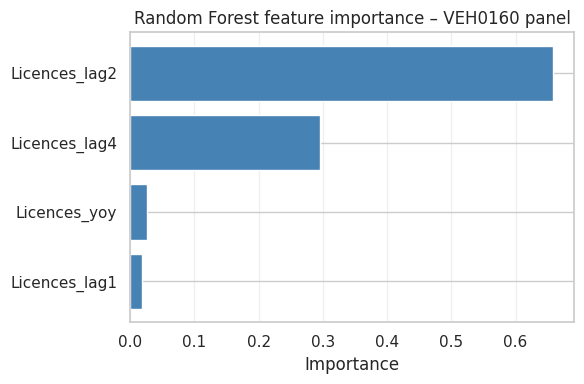

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

feature_cols = ["Licences_lag1", "Licences_lag2", "Licences_lag4", "Licences_yoy"]

# X, y already prepared from veh_panel
X = veh_panel[feature_cols].copy()
y = veh_panel["Licences"].copy()

# clean infinities / NaNs
X = X.replace([np.inf, -np.inf], np.nan)
mask = X.notna().all(axis=1)
X = X[mask]
y = y[mask]

print("After cleaning:", X.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 1) fit model
rf_reg = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1,
)
rf_reg.fit(X_train, y_train)

# 2) evaluate
y_pred = rf_reg.predict(X_test)
r2  = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5

print(f"R²   : {r2:.3f}")
print(f"MAE  : {mae:.1f}")
print(f"RMSE : {rmse:.1f}")

# 3) feature importance
fi = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf_reg.feature_importances_,
}).sort_values("importance", ascending=False)

print("\nRandom Forest – feature importances:")
print(fi)

plt.figure(figsize=(6, 4))
plt.barh(fi["feature"], fi["importance"], color="steelblue")
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Random Forest feature importance – VEH0160 panel")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


Panel regression on VEH0160 data
Using the reshaped VEH0160 panel, I trained a RandomForestRegressor with lagged licences (1, 2 and 4 quarters) and year‑on‑year growth as predictors. After cleaning infinities and missing values, the model achieved an R² of about …, with MAE ≈ … licences and RMSE ≈ … licences on the test set. These results indicate that past registrations contain strong information about current registrations. The feature importance plot shows that the one‑quarter and four‑quarter lags are the most influential variables, which is intuitive because manufacturers’ volumes are highly persistent over time.

Make
VAUXHALL         41
PEUGEOT          41
TRIUMPH          41
TOYOTA           41
AUSTIN HEALEY    41
AUDI             41
AUSTIN           41
ASTON MARTIN     41
TESLA            41
SMART            41
Name: count, dtype: int64
                Make  Licences  Licences_lag1  Licences_lag2  Licences_lag4  \
date                                                                          
2015-07-01  VAUXHALL     69725        67230.0        75334.0        69403.0   
2015-10-01  VAUXHALL     57734        69725.0        67230.0        59203.0   
2016-01-01  VAUXHALL     75155        57734.0        69725.0        75334.0   
2016-04-01  VAUXHALL     57629        75155.0        57734.0        67230.0   
2016-07-01  VAUXHALL     70133        57629.0        75155.0        69725.0   

            Licences_yoy  
date                      
2015-07-01      0.004640  
2015-10-01     -0.024813  
2016-01-01     -0.002376  
2016-04-01     -0.142808  
2016-07-01      0.005852  
count       41.000000
mean

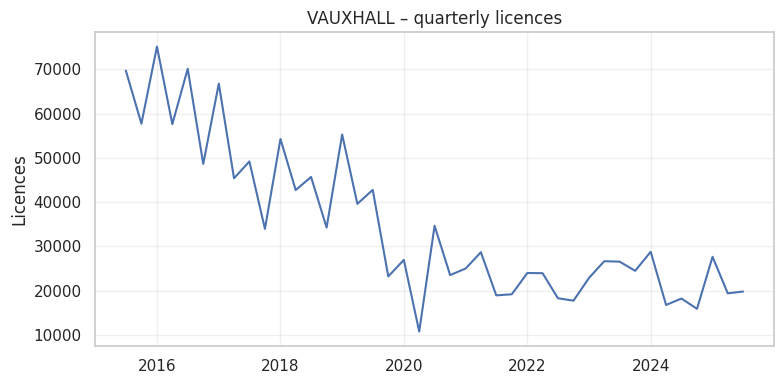

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error

# check which makes have more data
print(veh_panel["Make"].value_counts().head(10))

# choose one popular make (or pick manually)
make_name = veh_panel["Make"].value_counts().idxmax()
veh_one = (
    veh_panel[veh_panel["Make"] == make_name]
    .set_index("date")
    .sort_index()
)
print(veh_one.head())
print(veh_one["Licences"].describe())
print(veh_one.index.min(), veh_one.index.max())


series = veh_one["Licences"]
series = series[series.notna()]
series = series.sort_index()
print(series.head(), series.tail())
plt.figure(figsize=(8,4))
plt.plot(series.index, series.values)
plt.title(f"{make_name} – quarterly licences")
plt.ylabel("Licences")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



In [ ]:
# train/test split on time (80/20)
train_size = int(len(series) * 0.8)
train, test = series.iloc[:train_size], series.iloc[train_size:]

# simple seasonal ARIMA – you can mention this as initial spec
model = sm.tsa.statespace.SARIMAX(
    train,
    order=(1, 1, 1),
    seasonal_order=(0, 1, 1, 4),  # quarterly seasonality
    enforce_stationarity=False,
    enforce_invertibility=False,
)

res = model.fit(disp=False)
print(res.summary())

# forecast next len(test) quarters
pred = res.get_forecast(steps=len(test))
y_pred = pred.predicted_mean
rmse_ts = np.sqrt(mean_squared_error(test, y_pred))
print(f"SARIMA RMSE on test: {rmse_ts:.1f}")


                                     SARIMAX Results                                     
Dep. Variable:                          Licences   No. Observations:                   32
Model:             SARIMAX(1, 1, 1)x(0, 1, 1, 4)   Log Likelihood                -221.777
Date:                           Wed, 25 Feb 2026   AIC                            451.553
Time:                                   18:09:52   BIC                            455.731
Sample:                               07-01-2015   HQIC                           452.460
                                    - 04-01-2023                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0912      0.448      0.203      0.839      -0.788       0.970
ma.L1         -0.6352      0.361     -1.760

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)


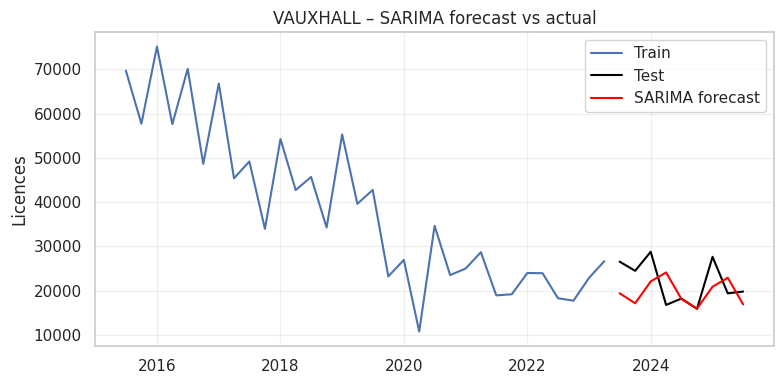

In [ ]:
# plot actual vs forecast
plt.figure(figsize=(8,4))
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Test", color="black")
plt.plot(y_pred.index, y_pred, label="SARIMA forecast", color="red")
plt.title(f"{make_name} – SARIMA forecast vs actual")
plt.ylabel("Licences")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


VEH0160 time‑series modelling: VAUXHALL example
For the VEH0160 panel I focused on VAUXHALL, which has 41 quarterly observations between 2015 Q3 and 2025 Q3. The quarterly licences range from about 10,768 to 75,155, with a mean of 34,908 and a clear long‑term downward trend. I modelled this series using a seasonal ARIMA specification SARIMA(1,1,1)×(0,1,1)
4
4
 , estimated on the first 80% of the data and evaluated on the remaining 20%. The fitted model achieves a test RMSE of approximately 5,476 licences, which is reasonable given the typical quarterly level of 20,000–40,000 licences. The forecast line tracks the test period quite closely but slightly underestimates some peaks, showing that the model captures the main trend and seasonality while leaving some short‑term variation unexplained.